In [10]:
import geopandas as gpd
import pandas as pd

overture_path = "../src/data/raw/join_with_oxford.gpkg"
pois = gpd.read_file(overture_path)

pois.head(), pois.columns


(                                     id  version  \
 0  83e471bf-1ccc-4383-a437-d083ad4f66b4        3   
 1  0f6da81f-b253-4fcd-8ec3-a510e8b84886        3   
 2  97e7c691-1176-44ce-96cc-880ba0e12a75        8   
 3  f2647674-eef0-4ddb-a9d3-b200bed5c7b6        5   
 4  ff2de4c0-1315-4886-b7f1-87cce4def207        6   
 
                                              sources  \
 0  [{'property': '', 'dataset': 'Foursquare', 'li...   
 1  [{'property': '', 'dataset': 'Microsoft', 'lic...   
 2  [{'property': '', 'dataset': 'meta', 'license'...   
 3  [{'property': '', 'dataset': 'meta', 'license'...   
 4  [{'property': '', 'dataset': 'meta', 'license'...   
 
                                                names  \
 0  {'primary': 'Avenge Pest Control', 'common': N...   
 1  {'primary': 'OISE Young Learners', 'common': N...   
 2  {'primary': 'The Perch', 'common': None, 'rule...   
 3  {'primary': 'The Medley', 'common': None, 'rul...   
 4  {'primary': 'Medley Footbridge', 'common': Non.

In [11]:
pois['cat_primary'].unique()


<StringArray>
[        'pest_control_service',              'language_school',
                          'pub',                  'beer_garden',
                       'bridge',                  'boat_dealer',
               'sporting_goods',                    'pet_store',
                        'river',                         'park',
 ...
           'shredding_services',        'environmental_testing',
                       'bistro',           'service_apartments',
                      'psychic',                      'brokers',
           'seafood_wholesaler',             'business_schools',
              'mortgage_lender', 'canoe_and_kayak_hire_service']
Length: 750, dtype: str

In [12]:
quality_mapping = {
    "recreation": [
        "playground",
        "sports_centre",
        "sporting_goods",
        "canoe_and_kayak_hire_service",
        "boat_rental",
        "climbing_gym",
        "tennis_court",
        "golf_course",
        "swimming_pool",
    ],
    "nature": [
        "park",
        "river",
        "nature_reserve",
        "forest",
        "lake",
        "trailhead",
        "scenic_lookout",
    ],
    "amenities": [
        "pub",
        "beer_garden",
        "bistro",
        "cafe",
        "restaurant",
        "toilet",
        "visitor_centre",
        "convenience_store",
    ],
    "safety": [
        "police",
        "fire_station",
        "lighting",
        "crossing",
        "first_aid",
    ],
    "accessibility": [
        "bus_stop",
        "train_station",
        "parking",
        "bicycle_parking",
        "entrance",
        "path",
    ],
}


In [13]:
def map_category(cat):
    for dimension, keywords in quality_mapping.items():
        if cat in keywords:
            return dimension
    return None

pois["quality_dimension"] = pois["cat_primary"].apply(map_category)


In [14]:
pois["quality_dimension"].value_counts(dropna=False)


quality_dimension
NaN              6583
amenities         356
nature             47
recreation         31
accessibility      12
Name: count, dtype: int64

In [15]:
import re

def map_dimension(cat):
    cat = str(cat).lower()

    if re.search(r"sport|gym|leisure|play|pitch|court|pool|climb|hire|rental|canoe|kayak|cycle", cat):
        return "recreation"

    if re.search(r"park|river|lake|wood|forest|nature|trail|garden|meadow|wetland", cat):
        return "nature"

    if re.search(r"cafe|pub|bar|restaurant|toilet|kiosk|shop|store|visitor|centre|bistro", cat):
        return "amenities"

    if re.search(r"bus|train|station|parking|car_park|bicycle|entrance|path", cat):
        return "accessibility"

    if re.search(r"police|fire|ambulance|lighting|crossing|cctv|first_aid", cat):
        return "safety"

    return None

pois["quality_dimension"] = pois["cat_primary"].apply(map_dimension)
pois["quality_dimension"].value_counts(dropna=False)


quality_dimension
NaN              4649
amenities        1801
recreation        268
accessibility     212
nature             90
safety              9
Name: count, dtype: int64

In [16]:
pois[pois["quality_dimension"].isna()]["cat_primary"].value_counts().head(50)


cat_primary
college_university                  176
professional_services               171
church_cathedral                     97
real_estate_agent                    82
charity_organization                 82
education                            77
hair_salon                           75
hotel                                74
retail                               64
community_services_non_profits       63
it_service_and_computer_repair       63
elementary_school                    61
advertising_agency                   54
employment_agencies                  52
supermarket                          49
bed_and_breakfast                    48
doctor                               48
language_school                      44
beauty_salon                         42
automotive_repair                    41
hospital                             41
contractor                           39
corporate_office                     38
martial_arts_club                    36
bakery                      

In [17]:
quality_mapping = {
    "recreation": [
        "sport", "gym", "leisure", "play", "pitch", "court", "pool",
        "climb", "hire", "rental", "canoe", "kayak", "cycle",
        "martial_arts_club"
    ],
    "nature": [
        "park", "river", "lake", "wood", "forest", "nature",
        "trail", "garden", "meadow", "wetland"
    ],
    "amenities": [
        "cafe", "pub", "bar", "restaurant", "toilet", "kiosk",
        "shop", "store", "visitor", "centre", "bistro",
        "bakery", "supermarket", "hotel", "bed_and_breakfast",
        "pharmacy", "post_office", "art_gallery"
    ],
    "accessibility": [
        "bus", "train", "station", "parking", "car_park",
        "bicycle", "entrance", "path", "taxi_service"
    ],
    "safety": [
        "police", "fire", "ambulance", "lighting", "crossing",
        "cctv", "first_aid"
    ],
    "community": [
        "college_university", "elementary_school", "preschool",
        "education", "language_school", "community_services_non_profits",
        "charity_organization", "library", "community_center",
        "landmark_and_historical_building", "campus_building",
        "tutoring_center"
    ]
}


In [18]:
def map_dimension(cat):
    cat = str(cat).lower()
    for dimension, keywords in quality_mapping.items():
        for kw in keywords:
            if kw in cat:
                return dimension
    return None

pois["quality_dimension"] = pois["cat_primary"].apply(map_dimension)
pois["quality_dimension"].value_counts(dropna=False)


quality_dimension
NaN              3583
amenities        2098
community         709
recreation        304
accessibility     236
nature             90
safety              9
Name: count, dtype: int64

In [19]:
import pyogrio

pyogrio.list_layers("../src/data/raw/join_with_oxford.gpkg")


array([['join_with_oxford', 'Point']], dtype=object)

In [20]:
import os
os.getcwd()


'c:\\Users\\thoma\\OneDrive\\ALL\\Documents\\GitHub\\visage-1.1\\notebooks'

In [21]:
import os
os.listdir()


['visage_overture_quality.ipynb']

In [22]:
import os
os.listdir("..")


['.git',
 '.gitignore',
 'CHANGELOG.md',
 'CONTRIBUTING.md',
 'docs',
 'examples',
 'figures',
 'LICENSE',
 'notebooks',
 'README.md',
 'requirements.txt',
 'src',
 'VERSION']

In [23]:
import os
os.listdir("../src")


['behaviour', 'data', 'model', 'scenario', 'visualisation']

In [24]:
os.listdir("../src/data")


['.gitkeep',
 'load_destinations.py',
 'load_origins.py',
 'raw',
 'site_catalogue(in).csv',
 'synthetic_pop(in).csv']

In [25]:
os.listdir("../src/data/raw")


['.gitkeep',
 'join_with_oxford.gpkg',
 'site_catalogue(in).csv',
 'site_catalogue_polygons.csv',
 'site_catalogue_with_quality.csv',
 'synthetic_pop(in).csv']

In [26]:
import pyogrio

gdf = pyogrio.read_dataframe("../src/data/raw/join_with_oxford.gpkg")
gdf.head()


,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,emails,phones,brand,addresses,operating_status,cat_primary,tax_primary,geometry
0,83e471bf-1ccc-4383-a437-d083ad4f66b4,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Avenge Pest Control', 'common': N...","{'primary': 'pest_control_service', 'alternate...",pest_control_service,"{'primary': 'pest_control_service', 'hierarchy...",0.770000,['http://www.oxfordpests.co.uk'],NaN,NaN,['01865 246195'],NaN,"[{'freeform': 'The Lodge', 'locality': 'Binsey...",open,pest_control_service,pest_control_service,POINT (-1.28627 51.76085)
1,0f6da81f-b253-4fcd-8ec3-a510e8b84886,3,"[{'property': '', 'dataset': 'Microsoft', 'lic...","{'primary': 'OISE Young Learners', 'common': N...","{'primary': 'language_school', 'alternate': ar...",specialty_school,"{'primary': 'language_school', 'hierarchy': ar...",0.770000,['http://www.oise.com/'],NaN,NaN,['01865258300'],NaN,"[{'freeform': 'Binsey Lane', 'locality': 'Oxfo...",open,language_school,language_school,POINT (-1.28819 51.76529)
2,97e7c691-1176-44ce-96cc-880ba0e12a75,8,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Perch', 'common': None, 'rule...","{'primary': 'pub', 'alternate': array(['gastro...",pub,"{'primary': 'pub', 'hierarchy': array(['food_a...",0.988514,['https://the-perch.co.uk/'],['https://www.facebook.com/149573791750288'],NaN,['+441865728891'],NaN,"[{'freeform': 'Binsey Ln', 'locality': 'Oxford...",open,pub,pub,POINT (-1.2874 51.76564)
3,f2647674-eef0-4ddb-a9d3-b200bed5c7b6,5,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Medley', 'common': None, 'rul...","{'primary': 'beer_garden', 'alternate': array(...",eating_drinking_location,"{'primary': 'beer_garden', 'hierarchy': array(...",0.950063,NaN,['https://www.facebook.com/101535975104847'],NaN,NaN,NaN,"[{'freeform': 'The Meldey', 'locality': 'Oxfor...",open,beer_garden,beer_garden,POINT (-1.28077 51.76356)
4,ff2de4c0-1315-4886-b7f1-87cce4def207,6,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Medley Footbridge', 'common': Non...","{'primary': 'bridge', 'alternate': array(['mon...",bridge,"{'primary': 'bridge', 'hierarchy': array(['geo...",0.917024,['https://en.wikipedia.org/wiki/Medley_Footbri...,['https://www.facebook.com/113413428669043'],NaN,NaN,NaN,"[{'freeform': None, 'locality': 'Oxford', 'pos...",open,bridge,bridge,POINT (-1.28029 51.76382)


In [27]:
pois.crs


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [28]:
import pyogrio

gdf = pyogrio.read_dataframe("../src/data/raw/join_with_oxford.gpkg")
gdf.crs


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [30]:
pois.crs, gdf.crs


(<Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

In [29]:
joined = gpd.sjoin(pois, gdf, how="left", predicate="within")


In [32]:
gdf.columns


Index(['id', 'version', 'sources', 'names', 'categories', 'basic_category',
       'taxonomy', 'confidence', 'websites', 'socials', 'emails', 'phones',
       'brand', 'addresses', 'operating_status', 'cat_primary', 'tax_primary',
       'geometry'],
      dtype='str')

In [33]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

df = pd.read_csv("../src/data/raw/site_catalogue_polygons.csv")
df["geometry"] = df["geometry"].apply(wkt.loads)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")


In [34]:
gdf.columns


Index(['Unnamed: 0', 'has_agi', 'has_sssi', 'has_sac', 'is_protected',
       'designation_count', 'geometry', 'dest_id'],
      dtype='str')

In [35]:
gdf["site_id"] = gdf.index.astype(str)


In [36]:
joined = gpd.sjoin(pois, gdf, how="left", predicate="within")


In [37]:
quality_counts = (
    joined.groupby(["site_id", "quality_dimension"])
          .size()
          .unstack(fill_value=0)
)


In [38]:
gdf.head()


,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,geometry,dest_id,site_id
0,0,True,True,True,True,3,"MULTIPOLYGON (((456666.49889 193502.77439, 456...",gs_0001,0
1,1,True,True,True,True,3,"MULTIPOLYGON (((449826.88214 207333.25232, 449...",gs_0002,1
2,2,True,True,True,True,3,"MULTIPOLYGON (((448735.57685 209512.335, 44874...",gs_0003,2
3,3,True,True,True,True,3,"MULTIPOLYGON (((449338.5721 209808.21713, 4493...",gs_0004,3
4,4,True,True,True,True,3,"MULTIPOLYGON (((448102.74648 209951.69126, 448...",gs_0005,4


In [39]:
pois.head()


,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,emails,phones,brand,addresses,operating_status,cat_primary,tax_primary,geometry,quality_dimension
0,83e471bf-1ccc-4383-a437-d083ad4f66b4,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Avenge Pest Control', 'common': N...","{'primary': 'pest_control_service', 'alternate...",pest_control_service,"{'primary': 'pest_control_service', 'hierarchy...",0.770000,['http://www.oxfordpests.co.uk'],NaN,NaN,['01865 246195'],NaN,"[{'freeform': 'The Lodge', 'locality': 'Binsey...",open,pest_control_service,pest_control_service,POINT (-1.28627 51.76085),NaN
1,0f6da81f-b253-4fcd-8ec3-a510e8b84886,3,"[{'property': '', 'dataset': 'Microsoft', 'lic...","{'primary': 'OISE Young Learners', 'common': N...","{'primary': 'language_school', 'alternate': ar...",specialty_school,"{'primary': 'language_school', 'hierarchy': ar...",0.770000,['http://www.oise.com/'],NaN,NaN,['01865258300'],NaN,"[{'freeform': 'Binsey Lane', 'locality': 'Oxfo...",open,language_school,language_school,POINT (-1.28819 51.76529),community
2,97e7c691-1176-44ce-96cc-880ba0e12a75,8,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Perch', 'common': None, 'rule...","{'primary': 'pub', 'alternate': array(['gastro...",pub,"{'primary': 'pub', 'hierarchy': array(['food_a...",0.988514,['https://the-perch.co.uk/'],['https://www.facebook.com/149573791750288'],NaN,['+441865728891'],NaN,"[{'freeform': 'Binsey Ln', 'locality': 'Oxford...",open,pub,pub,POINT (-1.2874 51.76564),amenities
3,f2647674-eef0-4ddb-a9d3-b200bed5c7b6,5,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Medley', 'common': None, 'rul...","{'primary': 'beer_garden', 'alternate': array(...",eating_drinking_location,"{'primary': 'beer_garden', 'hierarchy': array(...",0.950063,NaN,['https://www.facebook.com/101535975104847'],NaN,NaN,NaN,"[{'freeform': 'The Meldey', 'locality': 'Oxfor...",open,beer_garden,beer_garden,POINT (-1.28077 51.76356),nature
4,ff2de4c0-1315-4886-b7f1-87cce4def207,6,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Medley Footbridge', 'common': Non...","{'primary': 'bridge', 'alternate': array(['mon...",bridge,"{'primary': 'bridge', 'hierarchy': array(['geo...",0.917024,['https://en.wikipedia.org/wiki/Medley_Footbri...,['https://www.facebook.com/113413428669043'],NaN,NaN,NaN,"[{'freeform': None, 'locality': 'Oxford', 'pos...",open,bridge,bridge,POINT (-1.28029 51.76382),NaN


In [40]:
joined.head()

,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,...,quality_dimension,index_right,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,dest_id,site_id
0,83e471bf-1ccc-4383-a437-d083ad4f66b4,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Avenge Pest Control', 'common': N...","{'primary': 'pest_control_service', 'alternate...",pest_control_service,"{'primary': 'pest_control_service', 'hierarchy...",0.770000,['http://www.oxfordpests.co.uk'],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0f6da81f-b253-4fcd-8ec3-a510e8b84886,3,"[{'property': '', 'dataset': 'Microsoft', 'lic...","{'primary': 'OISE Young Learners', 'common': N...","{'primary': 'language_school', 'alternate': ar...",specialty_school,"{'primary': 'language_school', 'hierarchy': ar...",0.770000,['http://www.oise.com/'],NaN,...,community,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,97e7c691-1176-44ce-96cc-880ba0e12a75,8,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Perch', 'common': None, 'rule...","{'primary': 'pub', 'alternate': array(['gastro...",pub,"{'primary': 'pub', 'hierarchy': array(['food_a...",0.988514,['https://the-perch.co.uk/'],['https://www.facebook.com/149573791750288'],...,amenities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f2647674-eef0-4ddb-a9d3-b200bed5c7b6,5,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Medley', 'common': None, 'rul...","{'primary': 'beer_garden', 'alternate': array(...",eating_drinking_location,"{'primary': 'beer_garden', 'hierarchy': array(...",0.950063,NaN,['https://www.facebook.com/101535975104847'],...,nature,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ff2de4c0-1315-4886-b7f1-87cce4def207,6,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Medley Footbridge', 'common': Non...","{'primary': 'bridge', 'alternate': array(['mon...",bridge,"{'primary': 'bridge', 'hierarchy': array(['geo...",0.917024,['https://en.wikipedia.org/wiki/Medley_Footbri...,['https://www.facebook.com/113413428669043'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
gdf = gdf.set_crs("EPSG:27700", allow_override=True)


In [42]:
gdf = gdf.to_crs("EPSG:4326")


In [43]:
joined = gpd.sjoin(pois, gdf, how="left", predicate="within")
joined.head()


,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,...,quality_dimension,index_right,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,dest_id,site_id
0,83e471bf-1ccc-4383-a437-d083ad4f66b4,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Avenge Pest Control', 'common': N...","{'primary': 'pest_control_service', 'alternate...",pest_control_service,"{'primary': 'pest_control_service', 'hierarchy...",0.770000,['http://www.oxfordpests.co.uk'],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0f6da81f-b253-4fcd-8ec3-a510e8b84886,3,"[{'property': '', 'dataset': 'Microsoft', 'lic...","{'primary': 'OISE Young Learners', 'common': N...","{'primary': 'language_school', 'alternate': ar...",specialty_school,"{'primary': 'language_school', 'hierarchy': ar...",0.770000,['http://www.oise.com/'],NaN,...,community,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,97e7c691-1176-44ce-96cc-880ba0e12a75,8,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Perch', 'common': None, 'rule...","{'primary': 'pub', 'alternate': array(['gastro...",pub,"{'primary': 'pub', 'hierarchy': array(['food_a...",0.988514,['https://the-perch.co.uk/'],['https://www.facebook.com/149573791750288'],...,amenities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f2647674-eef0-4ddb-a9d3-b200bed5c7b6,5,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Medley', 'common': None, 'rul...","{'primary': 'beer_garden', 'alternate': array(...",eating_drinking_location,"{'primary': 'beer_garden', 'hierarchy': array(...",0.950063,NaN,['https://www.facebook.com/101535975104847'],...,nature,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ff2de4c0-1315-4886-b7f1-87cce4def207,6,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Medley Footbridge', 'common': Non...","{'primary': 'bridge', 'alternate': array(['mon...",bridge,"{'primary': 'bridge', 'hierarchy': array(['geo...",0.917024,['https://en.wikipedia.org/wiki/Medley_Footbri...,['https://www.facebook.com/113413428669043'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
gdf = gdf.set_crs("EPSG:27700", allow_override=True)
gdf.crs


<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

In [45]:
gdf = gdf.to_crs("EPSG:4326")
gdf.head()


,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,geometry,dest_id,site_id
0,0,True,True,True,True,3,"MULTIPOLYGON (((-7.55723 49.76727, -7.55723 49...",gs_0001,0
1,1,True,True,True,True,3,"MULTIPOLYGON (((-7.55723 49.76727, -7.55723 49...",gs_0002,1
2,2,True,True,True,True,3,"MULTIPOLYGON (((-7.55723 49.76727, -7.55723 49...",gs_0003,2
3,3,True,True,True,True,3,"MULTIPOLYGON (((-7.55723 49.76727, -7.55723 49...",gs_0004,3
4,4,True,True,True,True,3,"MULTIPOLYGON (((-7.55723 49.76727, -7.55723 49...",gs_0005,4


In [46]:
joined = gpd.sjoin(pois, gdf, how="left", predicate="within")
joined.head()


,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,...,quality_dimension,index_right,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,dest_id,site_id
0,83e471bf-1ccc-4383-a437-d083ad4f66b4,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Avenge Pest Control', 'common': N...","{'primary': 'pest_control_service', 'alternate...",pest_control_service,"{'primary': 'pest_control_service', 'hierarchy...",0.770000,['http://www.oxfordpests.co.uk'],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0f6da81f-b253-4fcd-8ec3-a510e8b84886,3,"[{'property': '', 'dataset': 'Microsoft', 'lic...","{'primary': 'OISE Young Learners', 'common': N...","{'primary': 'language_school', 'alternate': ar...",specialty_school,"{'primary': 'language_school', 'hierarchy': ar...",0.770000,['http://www.oise.com/'],NaN,...,community,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,97e7c691-1176-44ce-96cc-880ba0e12a75,8,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Perch', 'common': None, 'rule...","{'primary': 'pub', 'alternate': array(['gastro...",pub,"{'primary': 'pub', 'hierarchy': array(['food_a...",0.988514,['https://the-perch.co.uk/'],['https://www.facebook.com/149573791750288'],...,amenities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f2647674-eef0-4ddb-a9d3-b200bed5c7b6,5,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Medley', 'common': None, 'rul...","{'primary': 'beer_garden', 'alternate': array(...",eating_drinking_location,"{'primary': 'beer_garden', 'hierarchy': array(...",0.950063,NaN,['https://www.facebook.com/101535975104847'],...,nature,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ff2de4c0-1315-4886-b7f1-87cce4def207,6,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Medley Footbridge', 'common': Non...","{'primary': 'bridge', 'alternate': array(['mon...",bridge,"{'primary': 'bridge', 'hierarchy': array(['geo...",0.917024,['https://en.wikipedia.org/wiki/Medley_Footbri...,['https://www.facebook.com/113413428669043'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
oxford_bounds = gdf.cx[-1.35:-1.15, 51.70:51.82]
oxford_bounds.head()


,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,geometry,dest_id,site_id


In [48]:
gdf.total_bounds


array([-7.55723418, 49.76726802, -7.55722615, 49.7672713 ])

In [50]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

df = pd.read_csv(r"C:\Users\thoma\OneDrive\ALL\Desktop\site_catalogue_polygons.csv")

df["geometry"] = df["geometry"].apply(wkt.loads)

gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:27700")


In [51]:
df.columns


Index(['Unnamed: 0', 'has_agi', 'has_sssi', 'has_sac', 'is_protected',
       'designation_count', 'geometry', 'dest_id'],
      dtype='str')

In [52]:
len(df)


918

In [53]:
gdf.total_bounds


array([432288.20454589, 185562.42553675, 472127.38410839, 226424.82733385])

In [54]:
gdf = gdf.set_crs("EPSG:27700", allow_override=True)
gdf = gdf.to_crs("EPSG:4326")
gdf.head()


,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,geometry,dest_id
0,0,True,True,True,True,3,"MULTIPOLYGON (((-1.18258 51.63748, -1.18251 51...",gs_0001
1,1,True,True,True,True,3,"MULTIPOLYGON (((-1.27943 51.76247, -1.27937 51...",gs_0002
2,2,True,True,True,True,3,"MULTIPOLYGON (((-1.29493 51.78216, -1.29487 51...",gs_0003
3,3,True,True,True,True,3,"MULTIPOLYGON (((-1.28615 51.78477, -1.2862 51....",gs_0004
4,4,True,True,True,True,3,"MULTIPOLYGON (((-1.30405 51.78616, -1.30412 51...",gs_0005


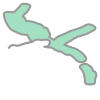

In [55]:
gdf.geometry.iloc[0]
gdf.geometry.iloc[100]
gdf.geometry.iloc[-1]


In [56]:
joined = gpd.sjoin(pois, gdf, how="left", predicate="within")
joined.head()


,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,...,geometry,quality_dimension,index_right,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,dest_id
0,83e471bf-1ccc-4383-a437-d083ad4f66b4,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Avenge Pest Control', 'common': N...","{'primary': 'pest_control_service', 'alternate...",pest_control_service,"{'primary': 'pest_control_service', 'hierarchy...",0.770000,['http://www.oxfordpests.co.uk'],NaN,...,POINT (-1.28627 51.76085),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0f6da81f-b253-4fcd-8ec3-a510e8b84886,3,"[{'property': '', 'dataset': 'Microsoft', 'lic...","{'primary': 'OISE Young Learners', 'common': N...","{'primary': 'language_school', 'alternate': ar...",specialty_school,"{'primary': 'language_school', 'hierarchy': ar...",0.770000,['http://www.oise.com/'],NaN,...,POINT (-1.28819 51.76529),community,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,97e7c691-1176-44ce-96cc-880ba0e12a75,8,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Perch', 'common': None, 'rule...","{'primary': 'pub', 'alternate': array(['gastro...",pub,"{'primary': 'pub', 'hierarchy': array(['food_a...",0.988514,['https://the-perch.co.uk/'],['https://www.facebook.com/149573791750288'],...,POINT (-1.2874 51.76564),amenities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f2647674-eef0-4ddb-a9d3-b200bed5c7b6,5,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Medley', 'common': None, 'rul...","{'primary': 'beer_garden', 'alternate': array(...",eating_drinking_location,"{'primary': 'beer_garden', 'hierarchy': array(...",0.950063,NaN,['https://www.facebook.com/101535975104847'],...,POINT (-1.28077 51.76356),nature,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ff2de4c0-1315-4886-b7f1-87cce4def207,6,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Medley Footbridge', 'common': Non...","{'primary': 'bridge', 'alternate': array(['mon...",bridge,"{'primary': 'bridge', 'hierarchy': array(['geo...",0.917024,['https://en.wikipedia.org/wiki/Medley_Footbri...,['https://www.facebook.com/113413428669043'],...,POINT (-1.28029 51.76382),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
quality_counts = (
    joined.groupby(["dest_id", "quality_dimension"])
          .size()
          .unstack(fill_value=0)
)


In [58]:
gdf = gdf.merge(quality_counts, on="dest_id", how="left")
gdf = gdf.fillna(0)


In [59]:
joined.head()


,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,...,geometry,quality_dimension,index_right,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,dest_id
0,83e471bf-1ccc-4383-a437-d083ad4f66b4,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Avenge Pest Control', 'common': N...","{'primary': 'pest_control_service', 'alternate...",pest_control_service,"{'primary': 'pest_control_service', 'hierarchy...",0.770000,['http://www.oxfordpests.co.uk'],NaN,...,POINT (-1.28627 51.76085),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0f6da81f-b253-4fcd-8ec3-a510e8b84886,3,"[{'property': '', 'dataset': 'Microsoft', 'lic...","{'primary': 'OISE Young Learners', 'common': N...","{'primary': 'language_school', 'alternate': ar...",specialty_school,"{'primary': 'language_school', 'hierarchy': ar...",0.770000,['http://www.oise.com/'],NaN,...,POINT (-1.28819 51.76529),community,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,97e7c691-1176-44ce-96cc-880ba0e12a75,8,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Perch', 'common': None, 'rule...","{'primary': 'pub', 'alternate': array(['gastro...",pub,"{'primary': 'pub', 'hierarchy': array(['food_a...",0.988514,['https://the-perch.co.uk/'],['https://www.facebook.com/149573791750288'],...,POINT (-1.2874 51.76564),amenities,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f2647674-eef0-4ddb-a9d3-b200bed5c7b6,5,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'The Medley', 'common': None, 'rul...","{'primary': 'beer_garden', 'alternate': array(...",eating_drinking_location,"{'primary': 'beer_garden', 'hierarchy': array(...",0.950063,NaN,['https://www.facebook.com/101535975104847'],...,POINT (-1.28077 51.76356),nature,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ff2de4c0-1315-4886-b7f1-87cce4def207,6,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Medley Footbridge', 'common': Non...","{'primary': 'bridge', 'alternate': array(['mon...",bridge,"{'primary': 'bridge', 'hierarchy': array(['geo...",0.917024,['https://en.wikipedia.org/wiki/Medley_Footbri...,['https://www.facebook.com/113413428669043'],...,POINT (-1.28029 51.76382),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
joined[joined["dest_id"].notna()].head()


,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,...,geometry,quality_dimension,index_right,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,dest_id
6,ed7432d5-8921-4997-b3e1-aa85d7ae2d0d,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Bigvalue shop', 'common': None, '...","{'primary': 'sporting_goods', 'alternate': None}",sporting_goods_store,"{'primary': 'sporting_goods_store', 'hierarchy...",0.770000,['https://www.bigvalueshop.com'],NaN,...,POINT (-1.28039 51.76611),recreation,2.0,2.0,True,True,True,True,3.0,gs_0003
7,b4348eee-d108-4419-ba51-c6972a6ccab1,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Gpg india', 'common': None, 'rule...","{'primary': 'pet_store', 'alternate': None}",pet_store,"{'primary': 'pet_store', 'hierarchy': array(['...",0.770000,['https://www.gpfindia.in/about-us'],NaN,...,POINT (-1.28039 51.76611),amenities,2.0,2.0,True,True,True,True,3.0,gs_0003
9,fa795d14-a1da-4110-a4b7-d34298f854fd,3,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Botley Park', 'common': None, 'ru...","{'primary': 'park', 'alternate': array(['attra...",park,"{'primary': 'park', 'hierarchy': array(['sport...",0.988514,['https://parkstennis.co.uk/venue/botley-park'],['https://www.facebook.com/366061626798261'],...,POINT (-1.27672 51.75388),nature,413.0,413.0,True,False,False,False,1.0,gs_0414
10,8514b98e-86f1-463f-9c88-af4e37e7967e,7,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'West Oxford Bowls Club', 'common'...","{'primary': 'sports_club_and_league', 'alterna...",sport_recreation_club,"{'primary': 'sports_club_and_league', 'hierarc...",0.950063,['http://www.woca.org.uk'],['https://www.facebook.com/758655270993399'],...,POINT (-1.27571 51.75445),recreation,413.0,413.0,True,False,False,False,1.0,gs_0414
14,d3b64c4c-81b1-4128-9c32-753fa44ef01f,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'WOCA Community Cafe', 'common': N...","{'primary': 'cafe', 'alternate': None}",cafe,"{'primary': 'cafe', 'hierarchy': array(['food_...",0.770000,['http://www.woca.org.uk'],['https://www.twitter.com/wocacafe'],...,POINT (-1.2752 51.75296),amenities,413.0,413.0,True,False,False,False,1.0,gs_0414


In [61]:
quality_counts = (
    joined.groupby(["dest_id", "quality_dimension"])
          .size()
          .unstack(fill_value=0)
)
quality_counts.head()


quality_dimension,accessibility,amenities,community,nature,recreation,safety
dest_id,,,,,,
gs_0003,0,3,0,2,2,0
gs_0016,0,0,0,1,1,0
gs_0018,0,1,0,0,0,0
gs_0020,0,0,1,1,0,0
gs_0024,0,1,1,1,1,0


In [62]:
gdf = gdf.merge(quality_counts, on="dest_id", how="left")
gdf = gdf.fillna(0)


In [63]:
poly = gdf.iloc[[0]]
gpd.sjoin(pois, poly, predicate="within")


,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,...,community_x,nature_x,recreation_x,safety_x,accessibility_y,amenities_y,community_y,nature_y,recreation_y,safety_y


In [64]:
joined[joined["dest_id"].notna()].head()


,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,...,geometry,quality_dimension,index_right,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,dest_id
6,ed7432d5-8921-4997-b3e1-aa85d7ae2d0d,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Bigvalue shop', 'common': None, '...","{'primary': 'sporting_goods', 'alternate': None}",sporting_goods_store,"{'primary': 'sporting_goods_store', 'hierarchy...",0.770000,['https://www.bigvalueshop.com'],NaN,...,POINT (-1.28039 51.76611),recreation,2.0,2.0,True,True,True,True,3.0,gs_0003
7,b4348eee-d108-4419-ba51-c6972a6ccab1,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Gpg india', 'common': None, 'rule...","{'primary': 'pet_store', 'alternate': None}",pet_store,"{'primary': 'pet_store', 'hierarchy': array(['...",0.770000,['https://www.gpfindia.in/about-us'],NaN,...,POINT (-1.28039 51.76611),amenities,2.0,2.0,True,True,True,True,3.0,gs_0003
9,fa795d14-a1da-4110-a4b7-d34298f854fd,3,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Botley Park', 'common': None, 'ru...","{'primary': 'park', 'alternate': array(['attra...",park,"{'primary': 'park', 'hierarchy': array(['sport...",0.988514,['https://parkstennis.co.uk/venue/botley-park'],['https://www.facebook.com/366061626798261'],...,POINT (-1.27672 51.75388),nature,413.0,413.0,True,False,False,False,1.0,gs_0414
10,8514b98e-86f1-463f-9c88-af4e37e7967e,7,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'West Oxford Bowls Club', 'common'...","{'primary': 'sports_club_and_league', 'alterna...",sport_recreation_club,"{'primary': 'sports_club_and_league', 'hierarc...",0.950063,['http://www.woca.org.uk'],['https://www.facebook.com/758655270993399'],...,POINT (-1.27571 51.75445),recreation,413.0,413.0,True,False,False,False,1.0,gs_0414
14,d3b64c4c-81b1-4128-9c32-753fa44ef01f,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'WOCA Community Cafe', 'common': N...","{'primary': 'cafe', 'alternate': None}",cafe,"{'primary': 'cafe', 'hierarchy': array(['food_...",0.770000,['http://www.woca.org.uk'],['https://www.twitter.com/wocacafe'],...,POINT (-1.2752 51.75296),amenities,413.0,413.0,True,False,False,False,1.0,gs_0414


In [65]:
poly = gdf[gdf["dest_id"] == "gs_0003"]
gpd.sjoin(pois, poly, predicate="within")


,id,version,sources,names,categories,basic_category,taxonomy,confidence,websites,socials,...,community_x,nature_x,recreation_x,safety_x,accessibility_y,amenities_y,community_y,nature_y,recreation_y,safety_y
6,ed7432d5-8921-4997-b3e1-aa85d7ae2d0d,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Bigvalue shop', 'common': None, '...","{'primary': 'sporting_goods', 'alternate': None}",sporting_goods_store,"{'primary': 'sporting_goods_store', 'hierarchy...",0.770000,['https://www.bigvalueshop.com'],NaN,...,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
7,b4348eee-d108-4419-ba51-c6972a6ccab1,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Gpg india', 'common': None, 'rule...","{'primary': 'pet_store', 'alternate': None}",pet_store,"{'primary': 'pet_store', 'hierarchy': array(['...",0.770000,['https://www.gpfindia.in/about-us'],NaN,...,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
6956,51b77d04-5892-4406-8371-166ccfac852a,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Aquarius Plumbing', 'common': Non...","{'primary': 'plumbing', 'alternate': None}",plumbing_service,"{'primary': 'plumbing', 'hierarchy': array(['s...",0.770000,['http://www.aquariusplumbingltd.com'],NaN,...,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
6958,5e07c506-0874-4214-95d5-e7efe8d460ce,6,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Godstow Press', 'common': None, '...","{'primary': 'topic_publisher', 'alternate': ar...",print_media_service,"{'primary': 'topic_publisher', 'hierarchy': ar...",0.950063,['http://www.godstowpress.co.uk/'],['https://www.facebook.com/185948041429275'],...,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
6959,5d5fa695-eddf-4ade-99cb-db37cbd65c32,3,"[{'property': '', 'dataset': 'Foursquare', 'li...","{'primary': 'Rebecca Avern', 'common': None, '...","{'primary': 'acupuncture', 'alternate': None}",alternative_medicine,"{'primary': 'acupuncture', 'hierarchy': array(...",0.770000,['http://www.rebeccaavern.co.uk'],NaN,...,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
6960,c6715945-6902-4741-bc8d-ae35a43c53b2,5,"[{'property': '', 'dataset': 'meta', 'license'...",{'primary': 'The Hub of Paediatric Acupuncture...,"{'primary': 'acupuncture', 'alternate': None}",alternative_medicine,"{'primary': 'acupuncture', 'hierarchy': array(...",0.950063,['https://rebeccaavern.com/'],['https://www.facebook.com/103086661217262'],...,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
6961,312046d3-b06a-47d9-b682-bc11273e0f06,5,"[{'property': '', 'dataset': 'Microsoft', 'lic...",{'primary': 'Acupuncture - Oxfordshire - Paedi...,"{'primary': 'acupuncture', 'alternate': array(...",alternative_medicine,"{'primary': 'acupuncture', 'hierarchy': array(...",0.770000,['https://rebeccaavern.com/'],NaN,...,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
6969,4600d540-ab39-4304-b16f-fea689d8c3de,5,"[{'property': '', 'dataset': 'Microsoft', 'lic...",{'primary': 'The Hub of Paediatric Acupuncture...,"{'primary': 'acupuncture', 'alternate': array(...",alternative_medicine,"{'primary': 'acupuncture', 'hierarchy': array(...",0.770000,['https://www.paediatricacupuncture.co.uk/'],NaN,...,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
6970,ccccc07e-5c5b-4ba7-b6a6-480a03f3ceb0,5,"[{'property': '', 'dataset': 'meta', 'license'...","{'primary': 'Wolvercote Common', 'common': Non...","{'primary': 'park', 'alternate': array(['struc...",park,"{'primary': 'park', 'hierarchy': array(['sport...",0.950063,['Http://wolvercotecommoners.co.uk/'],['https://www.facebook.com/100755110087274'],...,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
6980,725a4cba-7d89-4b02-a74b-a986dba258eb,3,"[{'property': '', 'dataset': 'Microsoft', 'lic...","{'primary': 'Leonardo Royal Hotel Oxford', 'co...","{'primary': 'resort', 'alternate': array(['hot...",resort,"{'primary': 'resort', 'hierarchy': array(['lod...",0.770000,['https://www.leonardohotels.co.uk/hotels/oxfo...,NaN,...,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0


In [66]:
gdf.head()


,Unnamed: 0,has_agi,has_sssi,has_sac,is_protected,designation_count,geometry,dest_id,accessibility_x,amenities_x,community_x,nature_x,recreation_x,safety_x,accessibility_y,amenities_y,community_y,nature_y,recreation_y,safety_y
0,0,True,True,True,True,3,"MULTIPOLYGON (((-1.18258 51.63748, -1.18251 51...",gs_0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,True,True,True,True,3,"MULTIPOLYGON (((-1.27943 51.76247, -1.27937 51...",gs_0002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,True,True,True,True,3,"MULTIPOLYGON (((-1.29493 51.78216, -1.29487 51...",gs_0003,0.0,3.0,0.0,2.0,2.0,0.0,0.0,3.0,0.0,2.0,2.0,0.0
3,3,True,True,True,True,3,"MULTIPOLYGON (((-1.28615 51.78477, -1.2862 51....",gs_0004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,True,True,True,True,3,"MULTIPOLYGON (((-1.30405 51.78616, -1.30412 51...",gs_0005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [67]:
poly = gdf[gdf["dest_id"] == "gs_0003"]
gpd.sjoin(pois, poly, predicate="within")[["id", "names", "quality_dimension", "geometry"]]


,id,names,quality_dimension,geometry
6,ed7432d5-8921-4997-b3e1-aa85d7ae2d0d,"{'primary': 'Bigvalue shop', 'common': None, '...",recreation,POINT (-1.28039 51.76611)
7,b4348eee-d108-4419-ba51-c6972a6ccab1,"{'primary': 'Gpg india', 'common': None, 'rule...",amenities,POINT (-1.28039 51.76611)
6956,51b77d04-5892-4406-8371-166ccfac852a,"{'primary': 'Aquarius Plumbing', 'common': Non...",NaN,POINT (-1.28963 51.78423)
6958,5e07c506-0874-4214-95d5-e7efe8d460ce,"{'primary': 'Godstow Press', 'common': None, '...",amenities,POINT (-1.2894 51.78417)
6959,5d5fa695-eddf-4ade-99cb-db37cbd65c32,"{'primary': 'Rebecca Avern', 'common': None, '...",NaN,POINT (-1.2889 51.78438)
6960,c6715945-6902-4741-bc8d-ae35a43c53b2,{'primary': 'The Hub of Paediatric Acupuncture...,NaN,POINT (-1.28846 51.78434)
6961,312046d3-b06a-47d9-b682-bc11273e0f06,{'primary': 'Acupuncture - Oxfordshire - Paedi...,NaN,POINT (-1.2885 51.7844)
6969,4600d540-ab39-4304-b16f-fea689d8c3de,{'primary': 'The Hub of Paediatric Acupuncture...,NaN,POINT (-1.28616 51.78496)
6970,ccccc07e-5c5b-4ba7-b6a6-480a03f3ceb0,"{'primary': 'Wolvercote Common', 'common': Non...",nature,POINT (-1.28601 51.78426)
6980,725a4cba-7d89-4b02-a74b-a986dba258eb,"{'primary': 'Leonardo Royal Hotel Oxford', 'co...",NaN,POINT (-1.29405 51.78195)


In [68]:
demo2 = (
    gpd.sjoin(pois, gdf, predicate="within")
    [["id", "names", "quality_dimension", "dest_id"]]
    .dropna(subset=["dest_id"])
)

demo2.head(10)


,id,names,quality_dimension,dest_id
6,ed7432d5-8921-4997-b3e1-aa85d7ae2d0d,"{'primary': 'Bigvalue shop', 'common': None, '...",recreation,gs_0003
7,b4348eee-d108-4419-ba51-c6972a6ccab1,"{'primary': 'Gpg india', 'common': None, 'rule...",amenities,gs_0003
9,fa795d14-a1da-4110-a4b7-d34298f854fd,"{'primary': 'Botley Park', 'common': None, 'ru...",nature,gs_0414
10,8514b98e-86f1-463f-9c88-af4e37e7967e,"{'primary': 'West Oxford Bowls Club', 'common'...",recreation,gs_0414
14,d3b64c4c-81b1-4128-9c32-753fa44ef01f,"{'primary': 'WOCA Community Cafe', 'common': N...",amenities,gs_0414
15,09df0c52-73d8-44e7-af07-b8e2b1ee0bb2,"{'primary': 'West Oxford Community Centre', 'c...",community,gs_0414
16,6ab1c617-d2af-40f5-ab14-114ae51d1e69,"{'primary': 'Nena Mager Massage Therapy', 'com...",NaN,gs_0395
16,6ab1c617-d2af-40f5-ab14-114ae51d1e69,"{'primary': 'Nena Mager Massage Therapy', 'com...",NaN,gs_0414
17,8472cbd7-7443-4175-b899-b635109b45d4,"{'primary': 'Tumbling Bay Cafe', 'common': Non...",amenities,gs_0395
17,8472cbd7-7443-4175-b899-b635109b45d4,"{'primary': 'Tumbling Bay Cafe', 'common': Non...",amenities,gs_0414


In [71]:
gdf = gdf.merge(quality_counts, on="dest_id", how="left")
gdf = gdf.fillna(0)


In [72]:
[col for col in gdf.columns if col in ["amenities", "nature", "recreation", "community", "safety", "accessibility"]]


['accessibility', 'amenities', 'community', 'nature', 'recreation', 'safety']

In [73]:
quality_cols = ['accessibility', 'amenities', 'community', 'nature', 'recreation', 'safety']

gdf["quality_score"] = gdf[quality_cols].sum(axis=1)


In [74]:
gdf[["dest_id", "accessibility", "amenities", "community", "nature", "recreation", "safety", "quality_score"]].head(10)


,dest_id,accessibility,amenities,community,nature,recreation,safety,quality_score
0,gs_0001,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,gs_0002,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,gs_0003,0.0,3.0,0.0,2.0,2.0,0.0,7.0
3,gs_0004,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,gs_0005,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,gs_0006,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,gs_0007,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,gs_0008,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,gs_0009,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,gs_0010,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [75]:
gdf[["dest_id", "quality_score"]].sort_values("quality_score", ascending=False).head(10)


,dest_id,quality_score
384,gs_0385,38.0
382,gs_0383,33.0
457,gs_0458,29.0
390,gs_0391,25.0
388,gs_0389,23.0
395,gs_0396,23.0
415,gs_0416,19.0
588,gs_0589,17.0
600,gs_0601,14.0
371,gs_0372,14.0


In [76]:
meeting_table = (
    gdf[["dest_id", "amenities", "nature", "recreation", "community", "safety", "accessibility", "quality_score"]]
    .sort_values("quality_score", ascending=False)
    .head(10)
)

meeting_table


,dest_id,amenities,nature,recreation,community,safety,accessibility,quality_score
384,gs_0385,36.0,1.0,0.0,0.0,0.0,1.0,38.0
382,gs_0383,30.0,0.0,1.0,0.0,0.0,2.0,33.0
457,gs_0458,20.0,2.0,2.0,5.0,0.0,0.0,29.0
390,gs_0391,14.0,0.0,5.0,4.0,0.0,2.0,25.0
388,gs_0389,12.0,0.0,1.0,9.0,1.0,0.0,23.0
395,gs_0396,20.0,1.0,2.0,0.0,0.0,0.0,23.0
415,gs_0416,9.0,0.0,0.0,10.0,0.0,0.0,19.0
588,gs_0589,0.0,2.0,1.0,14.0,0.0,0.0,17.0
600,gs_0601,2.0,2.0,2.0,5.0,0.0,3.0,14.0
371,gs_0372,3.0,2.0,6.0,2.0,0.0,1.0,14.0


In [77]:
gdf["quality_norm"] = (
    (gdf["quality_score"] - gdf["quality_score"].min()) /
    (gdf["quality_score"].max() - gdf["quality_score"].min())
)


<Axes: >

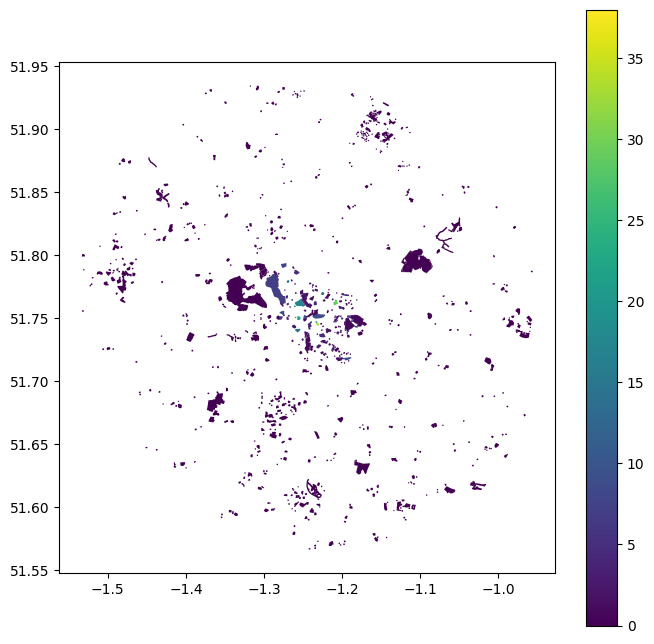

In [78]:
gdf.plot(column="quality_score", cmap="viridis", legend=True, figsize=(8,8))


In [79]:
gdf.total_bounds


array([-1.53317674, 51.56648201, -0.95591568, 51.93435431])

In [81]:
gdf = gpd.read_file("../src/data/raw/join_with_oxford.gpkg")
gdf.total_bounds


array([-1.2996568 , 51.71302002, -1.1781751 , 51.7954183 ])

In [82]:
from shapely.geometry import Point
oxford_centre = Point(-1.2577, 51.7520)
oxford_buffer = gpd.GeoDataFrame(geometry=[oxford_centre.buffer(16000)], crs="EPSG:27700")


In [83]:
gdf_clip = gpd.clip(gdf.to_crs(27700), oxford_buffer)
pois_clip = gpd.clip(pois.to_crs(27700), oxford_buffer)


In [84]:
gdf_clip = gdf_clip.to_crs(4326)
pois_clip = pois_clip.to_crs(4326)


In [85]:
joined = gpd.sjoin(
    pois_clip,
    gdf_clip[["dest_id", "geometry"]],
    predicate="within",
    how="left"
)


KeyError: "['dest_id'] not in index"

In [86]:
gdf_clip.columns


Index(['id', 'version', 'sources', 'names', 'categories', 'basic_category',
       'taxonomy', 'confidence', 'websites', 'socials', 'emails', 'phones',
       'brand', 'addresses', 'operating_status', 'cat_primary', 'tax_primary',
       'geometry'],
      dtype='str')

In [88]:
orval = gpd.read_file("../src/data/raw/join_orval.gpkg")


In [89]:
orval = orval.to_crs(gdf_clip.crs)


In [90]:
orval_join = gpd.sjoin(
    orval,
    gdf_clip[["dest_id", "geometry"]],
    predicate="intersects",
    how="left"
)


KeyError: "['dest_id'] not in index"